In [1]:
# Clone repo (for Google Colab – safe to re-run; no duplicate clone)
import os
REPO_DIR = "/content/Sigmoid-TopK-Fusion"  # Colab starts in /content
os.chdir("/content")
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/sriharshapy/Sigmoid-TopK-Fusion.git
%cd /content/Sigmoid-TopK-Fusion

Cloning into 'Sigmoid-TopK-Fusion'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 49 (delta 29), reused 32 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (49/49), 21.81 KiB | 10.91 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/Sigmoid-TopK-Fusion


In [2]:
!wget -q https://developer.download.nvidia.com/devtools/repos/ubuntu2204/amd64/NsightSystems-linux-cli-public-2024.6.1.90-3490548.deb -O nsys.deb
!dpkg -i nsys.deb || apt-get -f install -y
!nsys --version

Selecting previously unselected package nsight-systems-cli-2024.6.1.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack nsys.deb ...
Unpacking nsight-systems-cli-2024.6.1 (2024.6.1.90-246134905481v0) ...
Setting up nsight-systems-cli-2024.6.1 (2024.6.1.90-246134905481v0) ...
update-alternatives: using /opt/nvidia/nsight-systems-cli/2024.6.1/target-linux-x64/nsys to provide /usr/local/bin/nsys (nsys) in auto mode
NVIDIA Nsight Systems version 2024.6.1.90-246134905481v0


# Sigmoid + Top-K MoE: Benchmark & NCU Profiling

Runs both the **PyTorch** and **Triton** sigmoid+top-k implementations, then profiles them with **NVIDIA Nsight Compute (ncu)** and merges metrics into a CSV.

Pattern follows the [High-Performance-Reduction-Kernels](https://github.com/sriharshapy/High-Performance-Reduction-Kernels/tree/main/reductions/sum) example: warmup, timed runs, then NCU with `--target-processes all` (required to profile kernels launched by the Python process), metrics export to CSV, and merge.

## 1. Setup: ensure tensor.pt exists

In [3]:
import os
import subprocess
from pathlib import Path

ROOT = Path.cwd()
os.chdir(ROOT)
TENSOR_FILE = "tensor.pt"

if not Path(TENSOR_FILE).exists():
    print(f"Creating {TENSOR_FILE}...")
    subprocess.run(["python", "save_tensor.py", "-n", "16384", "-m", "128", "-o", TENSOR_FILE], check=True)
else:
    print(f"Using existing {TENSOR_FILE}")
print("Working directory:", os.getcwd())

Creating tensor.pt...
Working directory: /content/Sigmoid-TopK-Fusion


## 2. Run both scripts (benchmark: 3 warmup, 100 iters)

In [4]:
!python sigmoid_topk_moe_fused_pytorch.py -f tensor.pt -k 2 -n 100

Average over 100 runs: 1.3790 ms
topk_vals:
tensor([[0.9273, 0.9059],
        [0.9320, 0.8584],
        [0.9308, 0.9009],
        ...,
        [0.8884, 0.8850],
        [0.9449, 0.9277],
        [0.9706, 0.8721]], device='cuda:0')
topk_idx:
tensor([[  0,  48],
        [110,  67],
        [ 11,  73],
        ...,
        [  8,  63],
        [ 95,  55],
        [114,   3]], device='cuda:0', dtype=torch.int32)


In [5]:
!python sigmoid_topk_moe_fused_triton.py -f tensor.pt -k 2 -n 100

Average over 100 runs: 0.5021 ms
topk_vals:
tensor([[0.9273, 0.9059],
        [0.9320, 0.8584],
        [0.9308, 0.9009],
        ...,
        [0.8884, 0.8850],
        [0.9449, 0.9277],
        [0.9706, 0.8721]], device='cuda:0')
topk_idx:
tensor([[  0,  48],
        [110,  67],
        [ 11,  73],
        ...,
        [  8,  63],
        [ 95,  55],
        [114,   3]], device='cuda:0', dtype=torch.int32)


## 3. NCU profiling (detailed GPU metrics)

Runs `ncu` on both implementations with `--no-warmup` and 1 iteration, then exports raw CSV and merges. **Requires:** NVIDIA GPU, Nsight Compute installed, and scripts run on GPU (tensor on CUDA). If your tensor is on CPU, move it to CUDA first (e.g. in `save_tensor.py` or load with `map_location='cuda'`) for meaningful NCU results.

In [6]:
import csv
import io
import subprocess
import sys
from pathlib import Path

TENSOR_FILE = "tensor.pt"
OUTPUT_CSV = "ncu_merged.csv"
NCU = "ncu"
PYTHON = "python"
TRITON_SCRIPT = "sigmoid_topk_moe_fused_triton.py"
TORCH_SCRIPT = "sigmoid_topk_moe_fused_pytorch.py"

# One iteration, no warmup for clean NCU trace
APP_ARGS = ["-f", TENSOR_FILE, "-k", "2", "-n", "1", "--no-warmup", "--no-print"]

NCU_METRICS = (
    "gpu__time_duration.sum,"
    "dram__throughput.avg.pct_of_peak_sustained_elapsed,"
    "sm__warps_active.avg.pct_of_peak_sustained_active,"
    "smsp__thread_inst_executed_per_inst_executed.ratio,"
    "l1tex__throughput.avg.pct_of_peak_sustained_elapsed,"
    "l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_ld.sum,"
    "lts__t_sectors.avg.pct_of_peak_sustained_elapsed,"
    "l1tex__t_sector_hit_rate.pct,"
    "lts__t_sectors_srcunit_tex_op_read.sum,"
    "smsp__sass_average_data_bytes_per_sector_mem_global_op_ld.pct,"
    "dram__bytes_read.sum,"
    "dram__bytes_write.sum",
)

def run(cmd, timeout_s=1800):
    return subprocess.run(cmd, capture_output=True, text=True, timeout=timeout_s)

def profile_one(impl, run_cmd, kernel_regex=None, launch_count=None):
    rep = Path(f"report_{impl}.ncu-rep")
    cmd = [
        NCU,
        "--target-processes", "all",
        "--metrics", ",".join(NCU_METRICS),
        "-o", str(rep),
        "-f",
    ]
    if kernel_regex is not None:
        cmd += ["-k", f"regex:{kernel_regex}"]
    if launch_count is not None:
        cmd += ["-c", str(launch_count)]
    cmd += ["--"] + run_cmd

    print(f"[{impl}] {" ".join(cmd)}")
    r = run(cmd)
    if r.returncode != 0:
        print(f"[{impl}] ncu failed (returncode={r.returncode})", file=sys.stderr)
        if r.stdout:
            print(r.stdout[:2000], file=sys.stderr)
        if r.stderr:
            print(r.stderr[:2000], file=sys.stderr)
        return None
    if not rep.exists():
        print(f"[{impl}] Report missing: {rep}", file=sys.stderr)
        if r.stdout:
            print(r.stdout[:2000], file=sys.stderr)
        if r.stderr:
            print(r.stderr[:2000], file=sys.stderr)
        return None
    return rep

def export_csv(rep):
    cmd = [NCU, "-i", str(rep), "--csv", "--page", "raw"]
    r = run(cmd, timeout_s=180)
    if r.returncode != 0:
        print(f"[export] failed for {rep}", file=sys.stderr)
        return None
    return r.stdout

def parse_raw_csv(csv_text, impl):
    rows = list(csv.reader(io.StringIO(csv_text)))
    if not rows:
        return None
    header = rows[0]
    data_start = 1
    if len(rows) > 1 and rows[1] and rows[1][0] == "" and (
        "byte" in str(rows[1]).lower() or "ns" in str(rows[1]).lower() or "%" in str(rows[1])
    ):
        data_start = 2
    if "implementation" not in header:
        header = ["implementation"] + header
    n_cols = len(header) - 1
    out_rows = []
    for r in rows[data_start:]:
        if not r or (len(r) == 1 and not r[0].strip()):
            continue
        r = (r + [""] * n_cols)[:n_cols]
        out_rows.append([impl] + r)
    return header, out_rows

# Profile Triton (match our JIT kernel name)
reports = []
reports.append(("triton", profile_one(
    "triton",
    [PYTHON, TRITON_SCRIPT] + APP_ARGS,
    kernel_regex=r"sigmoid_topk",
    launch_count=1,
)))

# Profile PyTorch (capture relevant kernels; no filter = all kernels)
reports.append(("pytorch", profile_one(
    "pytorch",
    [PYTHON, TORCH_SCRIPT] + APP_ARGS,
    launch_count=None,
)))

reports = [(impl, rep) for impl, rep in reports if rep is not None]
if not reports:
    print("No .ncu-rep reports produced. NCU (NVIDIA Nsight Compute) is typically not available in Google Colab. Run this section on a machine with ncu installed and on PATH to generate reports.")
    print("Check ncu stdout/stderr above for details.")
else:
    merged_header = None
    merged_rows = []
    for impl, rep in reports:
        txt = export_csv(rep)
        if not txt:
            continue
        parsed = parse_raw_csv(txt, impl)
        if not parsed:
            continue
        header, rows = parsed
        if merged_header is None:
            merged_header = header
        merged_rows.extend(rows)
    if not merged_header or not merged_rows:
        print("No CSV data to write.")
    else:
        out_path = Path(OUTPUT_CSV)
        with open(out_path, "w", newline="", encoding="utf-8") as f:
            w = csv.writer(f)
            w.writerow(merged_header)
            w.writerows(merged_rows)
        print(f"Done. Wrote merged CSV: {out_path.resolve()}")
        print(f"Rows: {len(merged_rows)} (one per kernel launch)")

[triton] ncu --target-processes all --metrics gpu__time_duration.sum,dram__throughput.avg.pct_of_peak_sustained_elapsed,sm__warps_active.avg.pct_of_peak_sustained_active,smsp__thread_inst_executed_per_inst_executed.ratio,l1tex__throughput.avg.pct_of_peak_sustained_elapsed,l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_ld.sum,lts__t_sectors.avg.pct_of_peak_sustained_elapsed,l1tex__t_sector_hit_rate.pct,lts__t_sectors_srcunit_tex_op_read.sum,smsp__sass_average_data_bytes_per_sector_mem_global_op_ld.pct,dram__bytes_read.sum,dram__bytes_write.sum -o report_triton.ncu-rep -f -k regex:sigmoid_topk -c 1 -- python sigmoid_topk_moe_fused_triton.py -f tensor.pt -k 2 -n 1 --no-warmup --no-print
[pytorch] ncu --target-processes all --metrics gpu__time_duration.sum,dram__throughput.avg.pct_of_peak_sustained_elapsed,sm__warps_active.avg.pct_of_peak_sustained_active,smsp__thread_inst_executed_per_inst_executed.ratio,l1tex__throughput.avg.pct_of_peak_sustained_elapsed,l1tex__data_bank_conflicts_pip

## 3b. NSys profiling (stats to CSV)

Runs **Nsight Systems** (`nsys profile`) on both implementations, then exports stats (e.g. GPU kernel summary, API summary) to CSV and merges into `nsys_merged.csv`. Requires `nsys` on PATH.

In [7]:
import csv
import shutil
import subprocess
import sys
from pathlib import Path

failed_stats = []
if not shutil.which("nsys"):
    print("nsys (NVIDIA Nsight Systems) not found on PATH. Skip this cell or run on a machine with nsys installed.")
    merged_header = None
    merged_rows = []
else:
    TENSOR_FILE = "tensor.pt"
    APP_ARGS = ["-f", TENSOR_FILE, "-k", "2", "-n", "1", "--no-warmup", "--no-print"]
    PYTHON = "python"
    TRITON_SCRIPT = "sigmoid_topk_moe_fused_triton.py"
    TORCH_SCRIPT = "sigmoid_topk_moe_fused_pytorch.py"
    NSYS = "nsys"
    OUTPUT_NSYS_CSV = "nsys_merged.csv"
    NSYS_REPORTS = ["cuda_gpu_kern_sum", "cuda_api_sum"]

    def run(cmd, timeout_s=1800):
        return subprocess.run(cmd, capture_output=True, text=True, timeout=timeout_s)


    def nsys_profile_one(impl, run_cmd):
        rep = Path(f"report_{impl}.nsys-rep")
        cmd = [NSYS, "profile", "-o", str(rep.with_suffix("")), "--stats=false", "--force-overwrite=true"] + run_cmd
        print(f"[nsys {impl}] " + " ".join(cmd))
        r = run(cmd)
        if r.returncode != 0:
            print(f"[nsys {impl}] failed (returncode={r.returncode})", file=sys.stderr)
            if r.stderr:
                print(r.stderr[:1500], file=sys.stderr)
            return None
        if not rep.exists():
            print(f"[nsys {impl}] Report missing: {rep}", file=sys.stderr)
            return None
        return rep

    def nsys_export_csv(rep, report_name, impl):
        base = rep.with_suffix("").name
        cmd = [NSYS, "stats", str(rep), "--report", report_name, "--format", "csv", "--output", base, "--force-overwrite", "true", "--force-export", "true"]
        r = run(cmd, timeout_s=300)
        if r.returncode != 0:
            print(f"[nsys stats {impl} {report_name}] failed (returncode={r.returncode})", file=sys.stderr)
            if r.stderr:
                print(r.stderr[:2000], file=sys.stderr)
            if r.stdout:
                print(r.stdout[:1000], file=sys.stderr)
            return None
        out_path = Path(f"{base}_{report_name}.csv")
        if not out_path.exists():
            return None
        return out_path

    nsys_reports = []
    for impl, run_cmd in [("triton", [PYTHON, TRITON_SCRIPT] + APP_ARGS), ("pytorch", [PYTHON, TORCH_SCRIPT] + APP_ARGS)]:
        rep = nsys_profile_one(impl, run_cmd)
        if rep is not None:
            nsys_reports.append((impl, rep))

    merged_header = None
    merged_rows = []
    failed_stats = []
    for impl, rep in nsys_reports:
        for report_name in NSYS_REPORTS:
            csv_path = nsys_export_csv(rep, report_name, impl)
            if csv_path is None:
                failed_stats.append(f"{impl} {report_name}")
                continue
            with open(csv_path, newline="", encoding="utf-8") as f:
                reader = csv.reader(f)
                rows = list(reader)
            if not rows:
                continue
            header = ["implementation", "report"] + rows[0]
            for r in rows[1:]:
                merged_rows.append([impl, report_name] + r)
            if merged_header is None:
                merged_header = header

if merged_header and merged_rows:
    out_path = Path(OUTPUT_NSYS_CSV)
    with open(out_path, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(merged_header)
        w.writerows(merged_rows)
    print(f"Done. Wrote {out_path.resolve()} ({len(merged_rows)} rows)")
    if failed_stats:
        print("Skipped (stats failed): " + ", ".join(failed_stats), file=sys.stderr)
else:
    print("No nsys data to write. Ensure nsys is on PATH and reports were produced.")
    if failed_stats:
        print("Failed stats: " + ", ".join(failed_stats), file=sys.stderr)

[nsys triton] nsys profile -o report_triton --stats=false --force-overwrite=true python sigmoid_topk_moe_fused_triton.py -f tensor.pt -k 2 -n 1 --no-warmup --no-print
[nsys pytorch] nsys profile -o report_pytorch --stats=false --force-overwrite=true python sigmoid_topk_moe_fused_pytorch.py -f tensor.pt -k 2 -n 1 --no-warmup --no-print
Done. Wrote /content/Sigmoid-TopK-Fusion/nsys_merged.csv (20 rows)


## 4. View merged NCU metrics

## 5. NSys visualizations

Charts from `nsys_merged.csv`: GPU kernel time (1 vs 4 kernels), total time by implementation, and API call breakdown. Run the NSys profiling cell first to generate the CSV.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

nsys_path = Path("nsys_merged.csv")
if not nsys_path.is_file():
    raise FileNotFoundError(f"Run the NSys profiling cell first. Not found: {nsys_path}")
nsys_df = pd.read_csv(nsys_path)

# Numeric columns (nsys uses "Total Time (ns)", "Time (%)", etc.)
for c in ["Total Time (ns)", "Time (%)", "Instances", "Avg (ns)", "Min (ns)", "Max (ns)"]:
    if c in nsys_df.columns:
        nsys_df[c] = pd.to_numeric(nsys_df[c], errors="coerce")

def short_name_nsys(name):
    if pd.isna(name): return "unknown"
    s = str(name).strip()
    if "_sigmoid_topk_kernel" in s: return "sigmoid_topk (Triton)"
    if "gatherTopK" in s or "sbtopk" in s: return "topk"
    if "bitonicSort" in s: return "bitonic_sort"
    if "sigmoid_kernel" in s or "vectorized_elementwise" in s: return "sigmoid"
    if "direct_copy" in s or "unrolled_elementwise" in s: return "copy"
    if len(s) > 50: return s[:47] + "..."
    return s

nsys_df["Name_short"] = nsys_df["Name"].map(short_name_nsys)
kern_df = nsys_df[nsys_df["report"] == "cuda_gpu_kern_sum"].copy()
api_df = nsys_df[nsys_df["report"] == "cuda_api_sum"].copy()

# Style: dark theme, Triton green, PyTorch amber
plt.rcParams["figure.facecolor"] = "#0d1117"
plt.rcParams["axes.facecolor"] = "#161b22"
plt.rcParams["axes.edgecolor"] = "#30363d"
plt.rcParams["axes.labelcolor"] = "#e6edf3"
plt.rcParams["xtick.color"] = plt.rcParams["ytick.color"] = "#8b949e"
plt.rcParams["text.color"] = "#e6edf3"
NSYS_PALETTE = {"triton": "#3fb950", "pytorch": "#d29922"}
NSYS_EDGE = "#30363d"
print(f"NSys data: {len(kern_df)} kernel rows, {len(api_df)} API rows")

NSys data: 5 kernel rows, 15 API rows


### 5.1 GPU kernel time (1 vs 4 kernels)

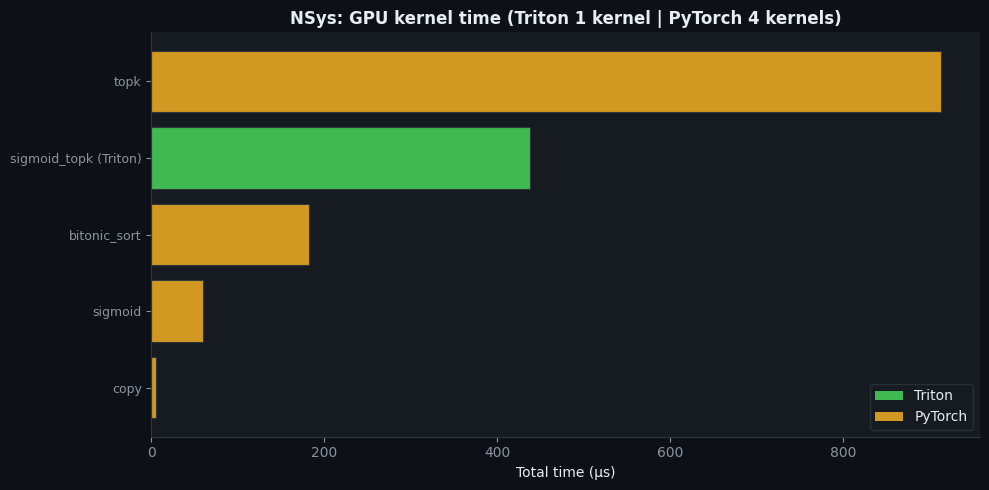

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
plot = kern_df.sort_values("Total Time (ns)", ascending=True)
y = np.arange(len(plot))
colors = [NSYS_PALETTE.get(x, "#58a6ff") for x in plot["implementation"]]
ax.barh(y, plot["Total Time (ns)"] / 1e3, color=colors, edgecolor=NSYS_EDGE, linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(plot["Name_short"], fontsize=9)
ax.set_xlabel("Total time (μs)")
ax.set_title("NSys: GPU kernel time (Triton 1 kernel | PyTorch 4 kernels)", fontsize=12, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend([plt.Rectangle((0,0),1,1, fc=NSYS_PALETTE["triton"]), plt.Rectangle((0,0),1,1, fc=NSYS_PALETTE["pytorch"])], ["Triton", "PyTorch"], loc="lower right", frameon=True, facecolor="#161b22", edgecolor=NSYS_EDGE)
plt.tight_layout()
plt.show()

### 5.2 Total kernel time by implementation

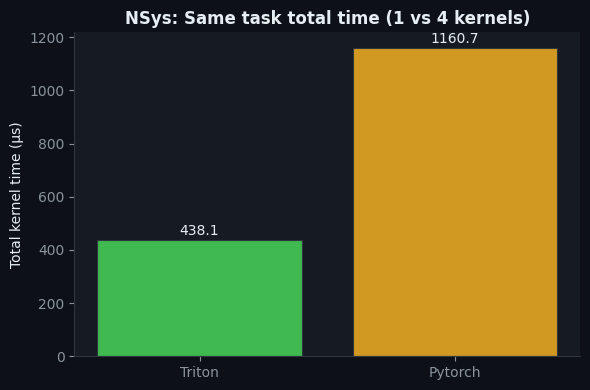

In [10]:
by_impl = kern_df.groupby("implementation")["Total Time (ns)"].sum()
by_impl = by_impl.reindex(["triton", "pytorch"]).dropna()
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(by_impl))
colors = [NSYS_PALETTE.get(i, "#58a6ff") for i in by_impl.index]
bars = ax.bar(x, by_impl.values / 1e3, color=colors, edgecolor=NSYS_EDGE, linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(by_impl.index.str.capitalize())
ax.set_ylabel("Total kernel time (μs)")
ax.set_title("NSys: Same task total time (1 vs 4 kernels)", fontsize=12, fontweight="bold")
for b, v in zip(bars, by_impl.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 5, f"{v/1e3:.1f}", ha="center", va="bottom", fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### 5.3 API call breakdown (top by total time)

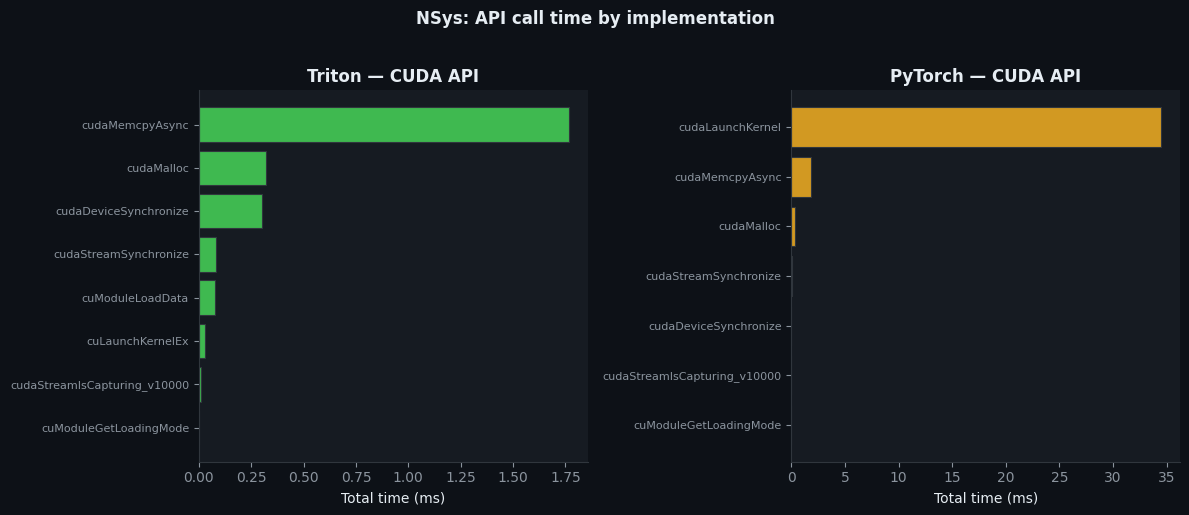

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (impl, label) in zip(axes, [("triton", "Triton"), ("pytorch", "PyTorch")]):
    sub = api_df[api_df["implementation"] == impl].sort_values("Total Time (ns)", ascending=True)
    y = np.arange(len(sub))
    ax.barh(y, sub["Total Time (ns)"] / 1e6, color=NSYS_PALETTE[impl], edgecolor=NSYS_EDGE, linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(sub["Name"], fontsize=8)
    ax.set_xlabel("Total time (ms)")
    ax.set_title(f"{label} — CUDA API", fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
plt.suptitle("NSys: API call time by implementation", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 5.4 Kernel time share (%)

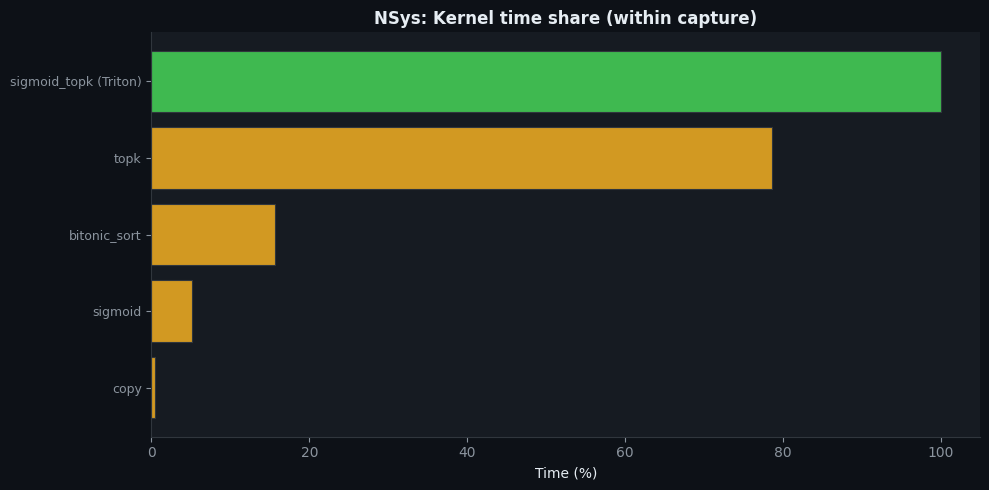

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
plot = kern_df.sort_values("Time (%)", ascending=True)
y = np.arange(len(plot))
colors = [NSYS_PALETTE.get(x, "#58a6ff") for x in plot["implementation"]]
ax.barh(y, plot["Time (%)"], color=colors, edgecolor=NSYS_EDGE, linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(plot["Name_short"], fontsize=9)
ax.set_xlabel("Time (%)")
ax.set_title("NSys: Kernel time share (within capture)", fontsize=12, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [13]:
import pandas as pd
from pathlib import Path

csv_path = Path("ncu_merged.csv")
if not csv_path.is_file():
    raise FileNotFoundError(f"Run the NCU cell first. Not found: {csv_path}")

df = pd.read_csv(csv_path)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
df

,implementation,ID,Process ID,Process Name,Host Name,Kernel Name,Context,Stream,Block Size,Grid Size,Device,CC,c2clink__enabled_mask,c2clink__present,device__attribute_architecture,device__attribute_async_engine_count,device__attribute_can_flush_remote_writes,device__attribute_can_map_host_memory,device__attribute_can_tex2d_gather,device__attribute_can_use_64_bit_stream_mem_ops,device__attribute_can_use_64_bit_stream_mem_ops_v1,device__attribute_can_use_host_pointer_for_registered_mem,device__attribute_can_use_stream_mem_ops_v1,device__attribute_can_use_stream_wait_value_nor,device__attribute_can_use_stream_wait_value_nor_v1,device__attribute_chip,device__attribute_clock_rate,device__attribute_cluster_launch,device__attribute_compute_capability_major,device__attribute_compute_capability_minor,device__attribute_compute_mode,device__attribute_compute_preemption_supported,device__attribute_concurrent_kernels,device__attribute_concurrent_managed_access,device__attribute_confidential_computing_mode,device__attribute_cooperative_launch,device__attribute_cooperative_multi_device_launch,device__attribute_deferred_mapping_cuda_array_supported,device__attribute_device_index,device__attribute_direct_managed_mem_access_from_host,device__attribute_display_name,device__attribute_dma_buf_supported,device__attribute_ecc_enabled,device__attribute_fb_bus_width,device__attribute_fbp_count,device__attribute_generic_compression_supported,device__attribute_global_l1_cache_supported,device__attribute_global_memory_bus_width,device__attribute_gpu_direct_rdma_flush_writes_options,device__attribute_gpu_direct_rdma_supported,device__attribute_gpu_direct_rdma_with_cuda_vmm_supported,device__attribute_gpu_direct_rdma_writes_ordering,device__attribute_gpu_overlap,device__attribute_gpu_pci_device_id,device__attribute_gpu_pci_ext_device_id,device__attribute_gpu_pci_ext_downstream_link_rate,device__attribute_gpu_pci_ext_downstream_link_width,device__attribute_gpu_pci_ext_gen,device__attribute_gpu_pci_ext_gpu_gen,device__attribute_gpu_pci_ext_gpu_link_rate,device__attribute_gpu_pci_ext_gpu_link_width,device__attribute_gpu_pci_revision_id,device__attribute_gpu_pci_sub_system_id,device__attribute_handle_type_fabric_supported,device__attribute_handle_type_posix_file_descriptor_supported,device__attribute_handle_type_win32_handle_supported,device__attribute_handle_type_win32_kmt_handle_supported,device__attribute_host_native_atomic_supported,device__attribute_host_numa_id,device__attribute_host_register_supported,device__attribute_implementation,device__attribute_integrated,device__attribute_ipc_event_supported,device__attribute_kernel_exec_timeout,device__attribute_l2_cache_size,device__attribute_l2s_count,device__attribute_limits_max_cta_per_sm,device__attribute_limits_num_tpcs,device__attribute_local_l1_cache_supported,device__attribute_managed_memory,device__attribute_max_access_policy_window_size,device__attribute_max_block_dim_x,device__attribute_max_block_dim_y,device__attribute_max_block_dim_z,device__attribute_max_blocks_per_multiprocessor,device__attribute_max_gpu_frequency_khz,device__attribute_max_grid_dim_x,device__attribute_max_grid_dim_y,device__attribute_max_grid_dim_z,device__attribute_max_ipc_per_multiprocessor,device__attribute_max_ipc_per_scheduler,device__attribute_max_mem_frequency_khz,device__attribute_max_persisting_l2_cache_size,device__attribute_max_pitch,device__attribute_max_registers_per_block,device__attribute_max_registers_per_multiprocessor,device__attribute_max_registers_per_thread,device__attribute_max_shared_memory_per_block,device__attribute_max_shared_memory_per_block_optin,device__attribute_max_shared_memory_per_multiprocessor,device__attribute_max_threads_per_block,device__attribute_max_threads_per_multiprocessor,device__attribute_max_warps_per_multiprocessor,device__attribute_max_warps_per_scheduler,device__attribute_maximum_surface1d_layered_layers,device__attribute_maximum_surface1d_layered_width,device__attribute_maximum_

## 6. NCU visualizations

After the NCU merged CSV is written above, run the cells below to plot kernel duration, DRAM throughput, warp occupancy, and memory traffic (uses `ncu_merged.csv` in the current directory).

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path("ncu_merged.csv")
if not csv_path.is_file():
    raise FileNotFoundError(f"Run the NCU cell first. Not found: {csv_path}")
df_raw = pd.read_csv(csv_path)

def to_num(s):
    if pd.isna(s): return np.nan
    if isinstance(s, (int, float)): return float(s)
    return float(str(s).replace(",", ""))

time_col = "gpu__time_duration.sum"
dram_read_col = "dram__bytes_read.sum"
dram_write_col = "dram__bytes_write.sum"
dram_thru_col = "dram__throughput.avg.pct_of_peak_sustained_elapsed"
warp_col = "sm__warps_active.avg.pct_of_peak_sustained_active"
l1tex_col = "l1tex__throughput.avg.pct_of_peak_sustained_elapsed"
for c in [time_col, dram_read_col, dram_write_col, dram_thru_col, warp_col, l1tex_col]:
    if c in df_raw.columns:
        df_raw[c] = df_raw[c].apply(to_num)

def short_name(name):
    if pd.isna(name): return "unknown"
    s = str(name).strip()
    if "_sigmoid_topk_kernel" in s: return "sigmoid_topk (Triton)"
    if "sigmoid_kernel_cuda" in s or "vectorized_elementwise" in s: return "sigmoid"
    if "gatherTopK" in s or "sbtopk" in s: return "topk"
    if "bitonicSort" in s: return "bitonic_sort"
    if "direct_copy" in s or "unrolled_elementwise" in s: return "copy"
    return s[:40] + "…" if len(s) > 40 else s

df_raw["kernel_short"] = df_raw["Kernel Name"].apply(short_name)
df_raw["impl"] = df_raw["implementation"].str.strip().str.lower()
df = df_raw.copy()

# Dark theme; Triton = green, PyTorch = amber
plt.rcParams["figure.facecolor"] = "#0d1117"
plt.rcParams["axes.facecolor"] = "#161b22"
plt.rcParams["axes.edgecolor"] = "#30363d"
plt.rcParams["axes.labelcolor"] = "#e6edf3"
plt.rcParams["xtick.color"] = plt.rcParams["ytick.color"] = "#8b949e"
plt.rcParams["text.color"] = "#e6edf3"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 10
PALETTE = {"triton": "#3fb950", "pytorch": "#d29922"}
BAR_EDGE = "#30363d"
# Per-task aggregates: Triton = 1 kernel, PyTorch = 4 kernels (same task)
n_kernels = df.groupby("impl").size().reindex(["triton", "pytorch"])
agg_task = df.groupby("impl").agg(
    time_sum=(time_col, "sum"),
    dram_read=(dram_read_col, "sum"),
    dram_write=(dram_write_col, "sum"),
).reindex(["triton", "pytorch"])
# Time-weighted avg for throughput/occupancy (kernels that run longer count more)
for col in [dram_thru_col, warp_col, l1tex_col]:
    num = (df[col] * df[time_col]).groupby(df["impl"]).sum()
    den = df.groupby("impl")[time_col].sum()
    agg_task[col] = (num / den).reindex(["triton", "pytorch"])
agg_task = agg_task.rename(columns={"time_sum": time_col})
print(f"Loaded {len(df)} kernel rows. Triton: {n_kernels.get('triton', 0)} kernel(s), PyTorch: {n_kernels.get('pytorch', 0)} kernel(s) (same task).")

Loaded 5 kernel rows. Triton: 1 kernel(s), PyTorch: 4 kernel(s) (same task).


### 1. Kernel duration — same task: Triton 1 launch vs PyTorch 4 launches

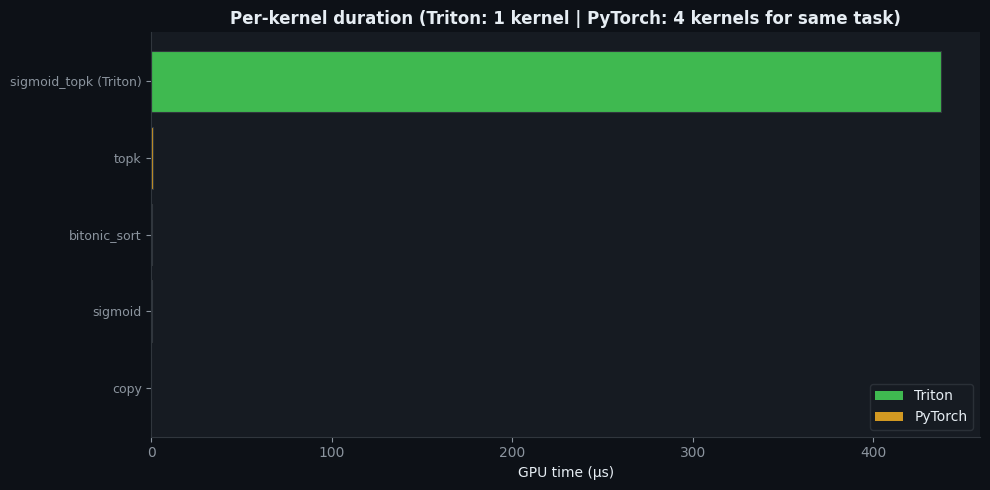

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = df.sort_values(time_col, ascending=True)
y_pos = np.arange(len(plot_df))
colors = [PALETTE.get(row["impl"], "#58a6ff") for _, row in plot_df.iterrows()]
ax.barh(y_pos, plot_df[time_col], color=colors, edgecolor=BAR_EDGE, linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["kernel_short"], fontsize=9)
ax.set_xlabel("GPU time (μs)")
ax.set_title("Per-kernel duration (Triton: 1 kernel | PyTorch: 4 kernels for same task)", fontsize=12, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend([plt.Rectangle((0,0),1,1, fc=PALETTE["triton"]), plt.Rectangle((0,0),1,1, fc=PALETTE["pytorch"])], ["Triton", "PyTorch"], loc="lower right", frameon=True, facecolor="#161b22", edgecolor=BAR_EDGE)
plt.tight_layout()
plt.show()

### 2. Total task time (Triton 1 kernel vs PyTorch 4 kernels)

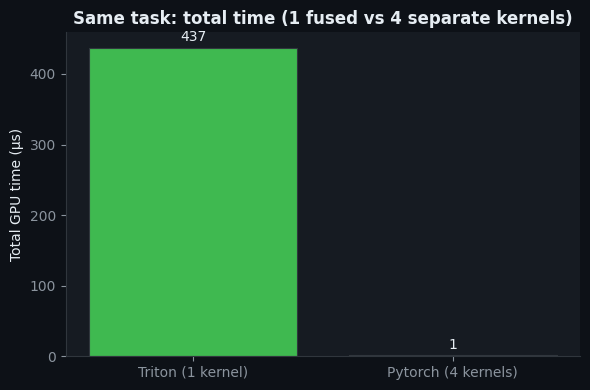

In [16]:
by_impl = agg_task[time_col].dropna()
labels = [f"{impl.capitalize()} ({int(n_kernels.get(impl, 0))} kernel" + ("s" if n_kernels.get(impl, 0) != 1 else "") + ")" for impl in by_impl.index]
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(by_impl))
colors = [PALETTE.get(i, "#58a6ff") for i in by_impl.index]
bars = ax.bar(x, by_impl.values, color=colors, edgecolor=BAR_EDGE, linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Total GPU time (μs)")
ax.set_title("Same task: total time (1 fused vs 4 separate kernels)", fontsize=12, fontweight="bold")
for b, v in zip(bars, by_impl.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 5, f"{v:.0f}", ha="center", va="bottom", fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### 3. Same-task: DRAM throughput & warp occupancy (time-weighted)

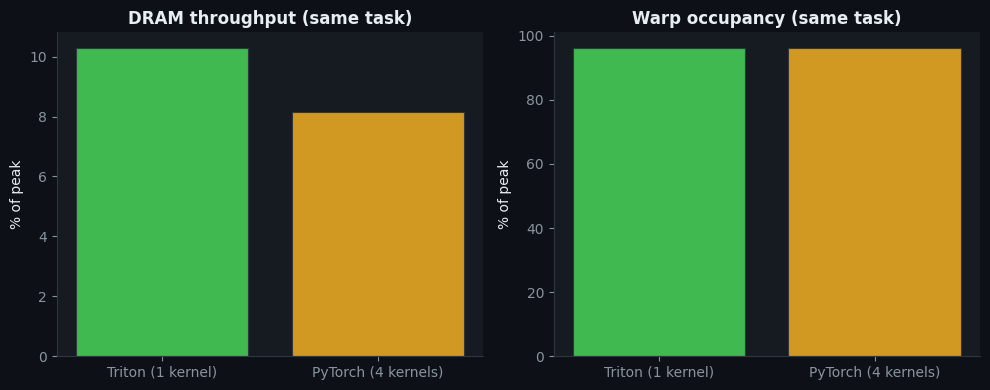

In [17]:
task_labels = [f"Triton (1 kernel)", f"PyTorch (4 kernels)"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x = np.arange(2)
colors = [PALETTE["triton"], PALETTE["pytorch"]]
axes[0].bar(x, agg_task[dram_thru_col].values, color=colors, edgecolor=BAR_EDGE, linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(task_labels)
axes[0].set_ylabel("% of peak")
axes[0].set_title("DRAM throughput (same task)", fontweight="bold")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[1].bar(x, agg_task[warp_col].values, color=colors, edgecolor=BAR_EDGE, linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(task_labels)
axes[1].set_ylabel("% of peak")
axes[1].set_title("Warp occupancy (same task)", fontweight="bold")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### 4. Same-task: DRAM bytes read / write (total)

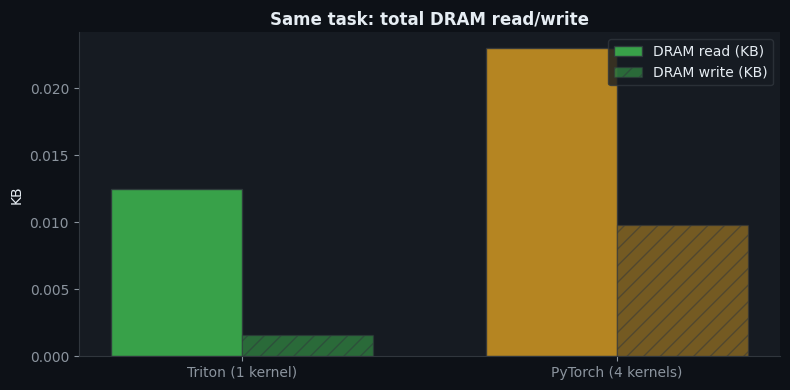

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(2)
w = 0.35
colors = [PALETTE["triton"], PALETTE["pytorch"]]
ax.bar(x - w/2, agg_task["dram_read"] / 1024, width=w, label="DRAM read (KB)", color=colors, alpha=0.85, edgecolor=BAR_EDGE)
ax.bar(x + w/2, agg_task["dram_write"] / 1024, width=w, label="DRAM write (KB)", color=colors, alpha=0.5, edgecolor=BAR_EDGE, hatch="//")
ax.set_xticks(x)
ax.set_xticklabels(["Triton (1 kernel)", "PyTorch (4 kernels)"])
ax.set_ylabel("KB")
ax.set_title("Same task: total DRAM read/write", fontsize=12, fontweight="bold")
ax.legend(loc="upper right", frameon=True, facecolor="#161b22", edgecolor=BAR_EDGE)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### 5. Same-task comparison (Triton 1 kernel vs PyTorch 4 kernels)

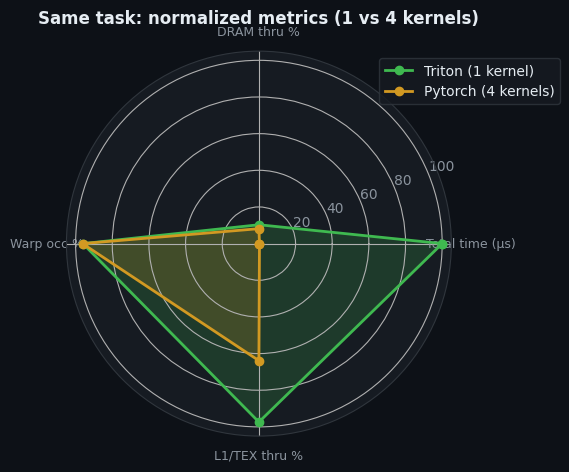

In [19]:
metrics = ["Total time (μs)", "DRAM thru %", "Warp occ %", "L1/TEX thru %"]
cols = [time_col, dram_thru_col, warp_col, l1tex_col]
M = np.array([[agg_task.loc[i, c] for c in cols] for i in agg_task.index])
norm = M.copy()
norm[:, 0] = M[:, 0] / (M[:, 0].max() or 1) * 100
norm[:, 1:] = np.nan_to_num(M[:, 1:], nan=0)
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection="polar"))
for i, impl in enumerate(agg_task.index):
    vals = norm[i].tolist() + [norm[i, 0]]
    nk = int(n_kernels.get(impl, 0))
    ax.plot(angles, vals, "o-", linewidth=2, label=impl.capitalize() + f" ({nk} kernel" + ("s" if nk != 1 else "") + ")", color=PALETTE.get(impl, "#58a6ff"))
    ax.fill(angles, vals, alpha=0.2, color=PALETTE.get(impl, "#58a6ff"))
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, size=9)
ax.set_ylim(0, 105)
ax.set_title("Same task: normalized metrics (1 vs 4 kernels)", fontsize=12, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1), frameon=True, facecolor="#161b22", edgecolor=BAR_EDGE)
plt.tight_layout()
plt.show()

### 6. Same-task: L1/TEX throughput (time-weighted)

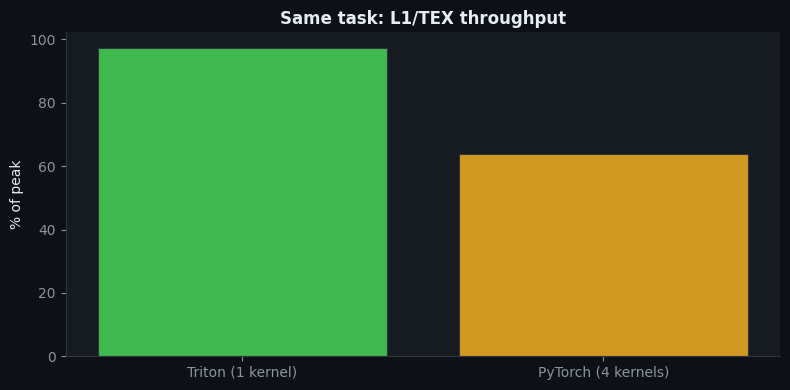

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(2)
colors = [PALETTE["triton"], PALETTE["pytorch"]]
ax.bar(x, agg_task[l1tex_col].values, color=colors, edgecolor=BAR_EDGE, linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(["Triton (1 kernel)", "PyTorch (4 kernels)"])
ax.set_ylabel("% of peak")
ax.set_title("Same task: L1/TEX throughput", fontsize=12, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()